# **MÓDULO 19**
# Exercício: Estatística Aplicada

**Efetividade de Duas Estratégias de Ensino**

Imagine que uma escola esteja avaliando a eficácia de duas estratégias de ensino de matemática para alunos do ensino médio. Eles querem determinar se há uma diferença significativa no desempenho médio dos alunos entre as duas estratégias.

# **Hipóteses:**

* Hipótese nula (H0): A média das notas dos alunos na estratégia A é igual à média das notas dos alunos na estratégia B.
* Hipótese alternativa (H1): A média das notas na Estratégia B é maior do que a média das notas na Estratégia A.

# **Dados:**

* Amostra da Estratégia A: Notas de 50 alunos que receberam a Estratégia A.
* Amostra da Estratégia B: Notas de 50 alunos que receberam a Estratégia B.

Usaremos um teste Z para comparar as médias das notas entre as duas amostras.

Se o p-valor do teste Z for menor que um nível de significância pré-determinado (por exemplo, α = 0.05), rejeitamos a hipótese nula e concluímos que há uma diferença significativa nas médias das notas entre as duas estratégias de ensino.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

Os dados são criados a seguir:

In [2]:
# Definindo médias e desvios padrão para as notas nas duas estratégias
media_estrategia_A = 70
desvio_padrao_estrategia_A = 10

media_estrategia_B = 75
desvio_padrao_estrategia_B = 12

# Gerando as amostras de notas para cada estratégia de ensino da nossa base
np.random.seed(0)  # Para garantir a reprodutibilidade dos resultados
amostra_estrategia_A = np.random.normal(loc=media_estrategia_A, scale=desvio_padrao_estrategia_A, size=50)
amostra_estrategia_B = np.random.normal(loc=media_estrategia_B, scale=desvio_padrao_estrategia_B, size=50)

print("Notas da Estratégia A:", amostra_estrategia_A[:5])
print("Notas da Estratégia B:", amostra_estrategia_B[:5])

Notas da Estratégia A: [87.64052346 74.00157208 79.78737984 92.40893199 88.6755799 ]
Notas da Estratégia B: [64.25440127 79.64282997 68.87033835 60.83241379 74.66181326]


# 1) De acordo com as informações analisadas o nosso teste é unilateral á direita, esquerda ou bicaudal? Justifique.




**Justificativa**
Com base nas hipóteses apresentadas, nosso teste é **unilateral à direita**. Isso ocorre porque a hipótese alternativa (H1) afirma que a média das notas dos alunos na Estratégia B é **maior** do que na Estratégia A, ou seja, estamos interessados apenas em verificar se a média de B supera a de A, e não se é diferente em qualquer direção (o que caracterizaria um teste bicaudal).

No teste unilateral à direita, a região crítica está na extremidade superior da distribuição, pois buscamos evidências de que a média de B é significativamente maior.

In [ ]:
# Sua justificativa aqui
# Justificativa prática: comparação das médias
# H0: média_B <= média_A
# H1: média_B > média_A (unilateral à direita)
print("Como a hipótese alternativa é média_B > média_A, o teste é unilateral à direita.")

# 2) Calcule as médias para as duas amostragens e as variâncias. Quais insights você pode retirar comparando os dados?

In [3]:
# Cálculo das médias e variâncias
media_A = np.mean(amostra_estrategia_A)
media_B = np.mean(amostra_estrategia_B)
variancia_A = np.var(amostra_estrategia_A, ddof=1)
variancia_B = np.var(amostra_estrategia_B, ddof=1)

print(f"Média Estratégia A: {media_A:.2f}")
print(f"Média Estratégia B: {media_B:.2f}")
print(f"Variância Estratégia A: {variancia_A:.2f}")
print(f"Variância Estratégia B: {variancia_B:.2f}")

# Insights
if media_B > media_A:
    print("A média das notas da Estratégia B é maior que a da Estratégia A.")
else:
    print("A média das notas da Estratégia A é maior ou igual à da Estratégia B.")

if variancia_B > variancia_A:
    print("A Estratégia B apresenta maior dispersão nas notas (maior variância).")
else:
    print("A Estratégia A apresenta maior dispersão nas notas (maior variância).")

Média Estratégia A: 71.41
Média Estratégia B: 74.75
Variância Estratégia A: 129.27
Variância Estratégia B: 110.47
A média das notas da Estratégia B é maior que a da Estratégia A.
A Estratégia A apresenta maior dispersão nas notas (maior variância).


# 3) Imprima os resultados da estatística do teste Z, p value e indique se rejeitaremos ou não a hipótese nula. Justifique sua resposta.

In [4]:
#Seu código aqui

# Cálculo do teste Z para duas amostras independentes
n_A = len(amostra_estrategia_A)
n_B = len(amostra_estrategia_B)

# Erro padrão da diferença entre as médias
erro_padrao = np.sqrt(variancia_A/n_A + variancia_B/n_B)

# Estatística Z
z = (media_B - media_A) / erro_padrao

# p-valor (unilateral à direita)
p_value = 1 - stats.norm.cdf(z)

print(f"Estatística Z: {z:.2f}")
print(f"p-valor: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("Rejeitamos a hipótese nula: há evidências de que a média da Estratégia B é maior.")
else:
    print("Não rejeitamos a hipótese nula: não há evidências suficientes de que a média da Estratégia B é maior.")

Estatística Z: 1.53
p-valor: 0.0634
Não rejeitamos a hipótese nula: não há evidências suficientes de que a média da Estratégia B é maior.


# 4) Para finalizar monte o gráfico da distribuição da estatística do nosso teste Z e explique o que pode ser observado através dele.

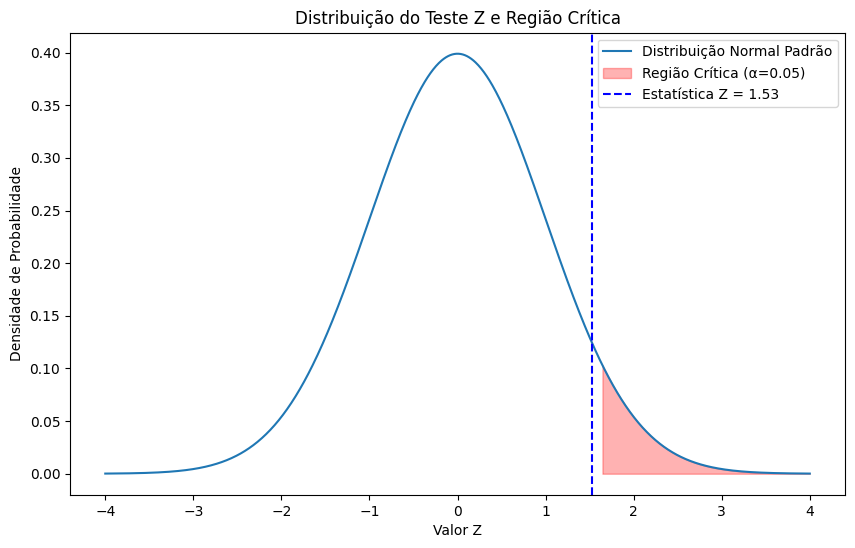

A área em vermelho representa a região crítica do teste (valores de Z maiores que o valor crítico para α=0.05).
Se a estatística Z estiver nessa região, rejeitamos H0. Observe onde a linha azul (Z calculado) está em relação à região crítica.


In [5]:
#Seu código aqui
# Visualização da distribuição do teste Z
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x, 0, 1)

plt.figure(figsize=(10,6))
plt.plot(x, y, label='Distribuição Normal Padrão')
plt.fill_between(x, 0, y, where=(x > stats.norm.ppf(0.95)), color='red', alpha=0.3, label='Região Crítica (α=0.05)')
plt.axvline(z, color='blue', linestyle='--', label=f'Estatística Z = {z:.2f}')
plt.title('Distribuição do Teste Z e Região Crítica')
plt.xlabel('Valor Z')
plt.ylabel('Densidade de Probabilidade')
plt.legend()
plt.show()

print("A área em vermelho representa a região crítica do teste (valores de Z maiores que o valor crítico para α=0.05).")
print("Se a estatística Z estiver nessa região, rejeitamos H0. Observe onde a linha azul (Z calculado) está em relação à região crítica.")